<h2>Steps in the model building</h2>
<ul>
    <li>1.importing dataset</li>
    <li>preprocessing : nullvalue,duplicate value remove</li>
    <li>visualize the datset</li>
    <li>train the model</li>
</ul>

<h2> Dataset importing and preprocessing </h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("crop_yield.csv")
df.head()


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [3]:
df.shape

(19689, 10)

In [4]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


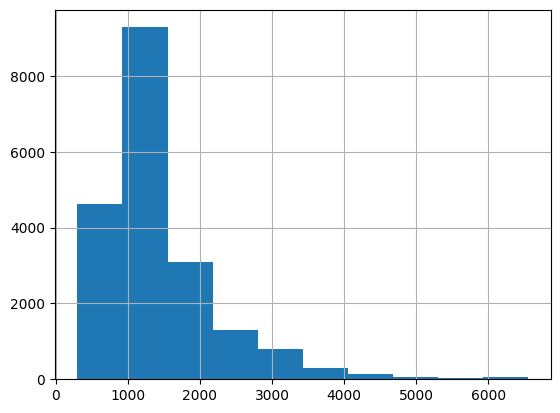

In [8]:
df['Annual_Rainfall'].hist()
plt.show()

In [9]:
# df['Annual_Rainfall'].bar()    
# plt.show()

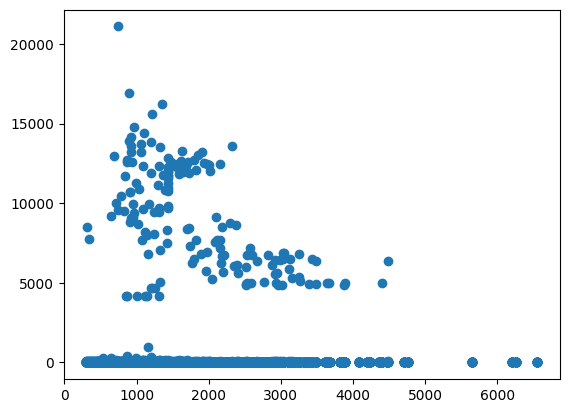

In [10]:
plt.scatter(df['Annual_Rainfall'],df['Yield'])

<Axes: xlabel='count', ylabel='State'>

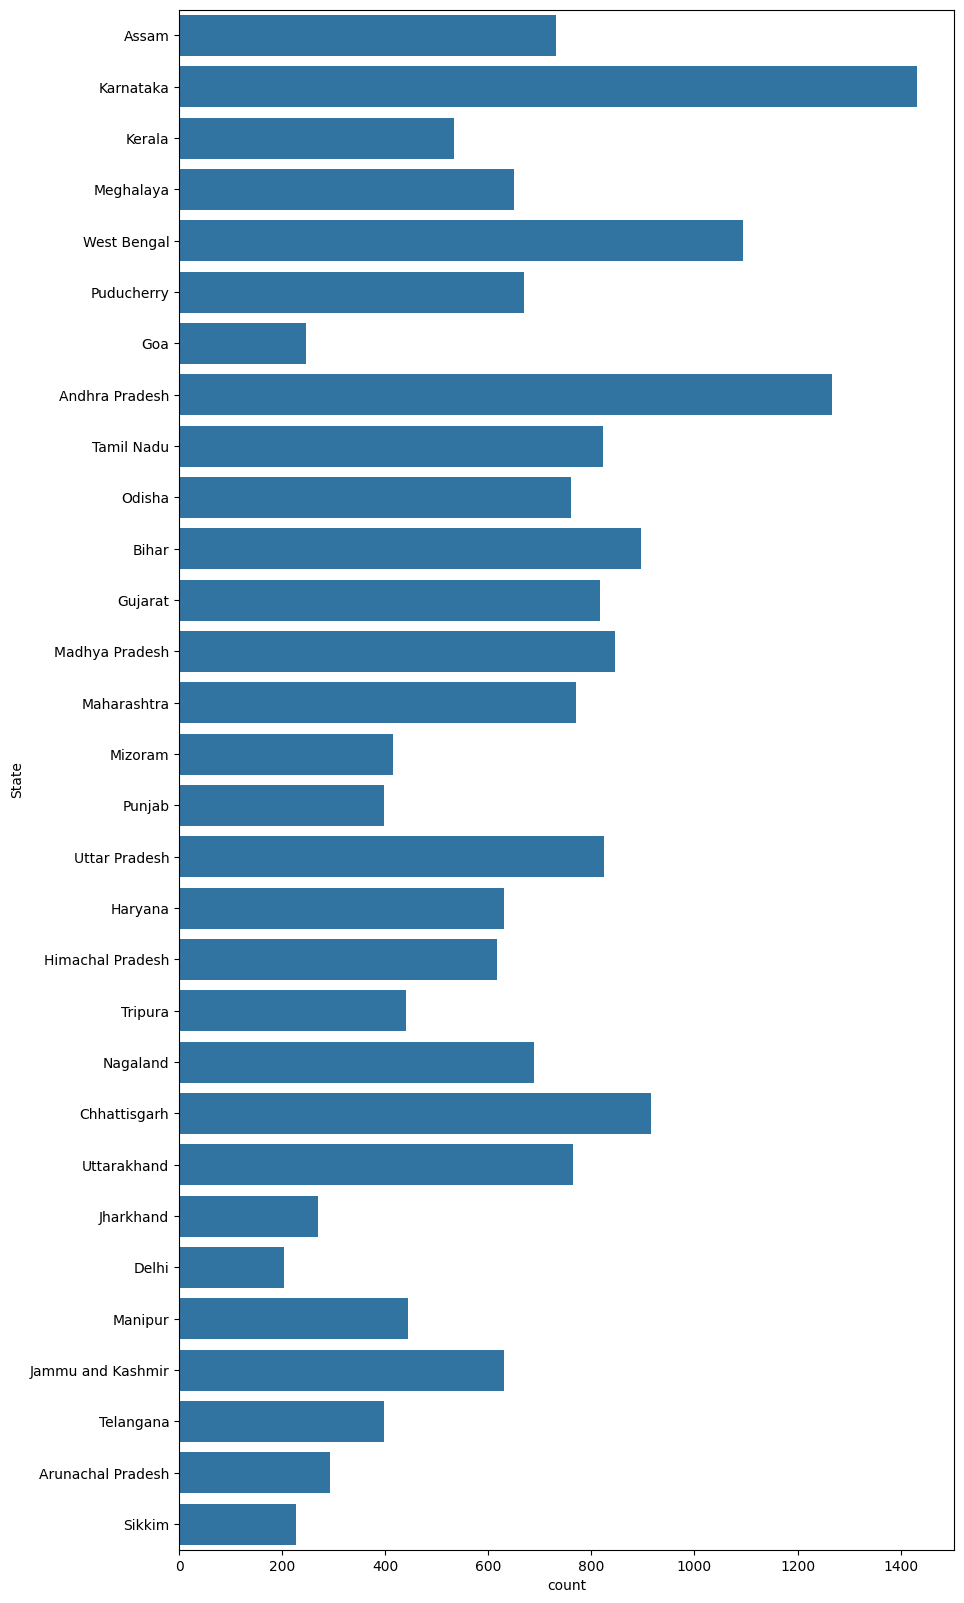

In [11]:
plt.figure(figsize = (10,20))
sns.countplot(y=df['State'])

<Axes: xlabel='count', ylabel='Crop'>

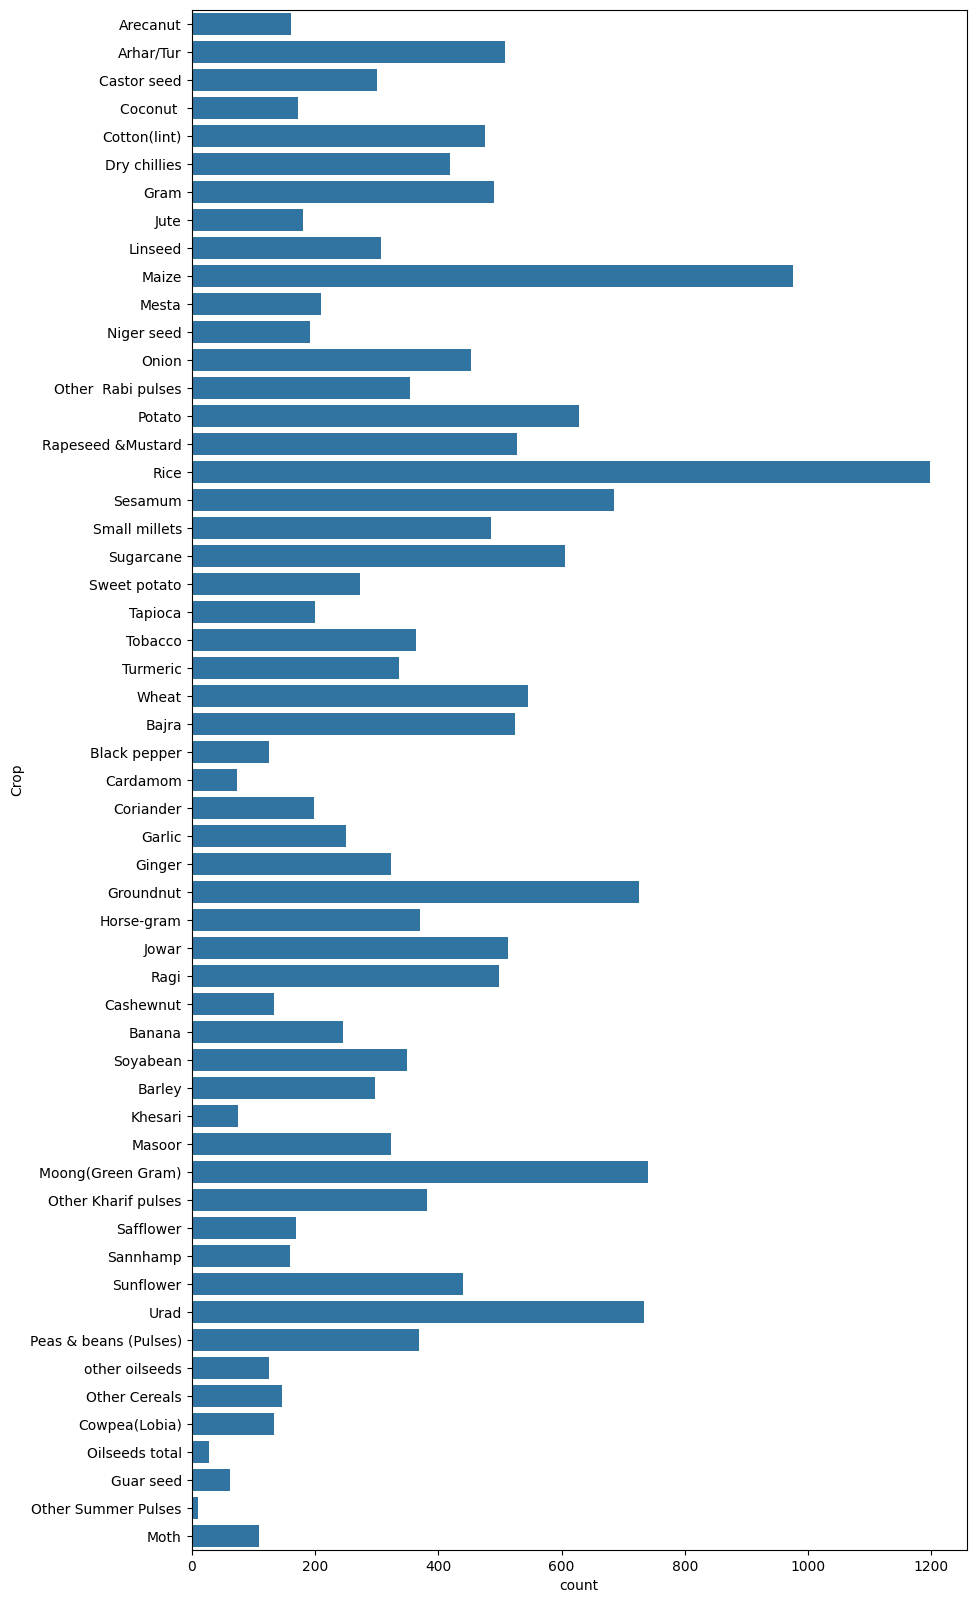

In [12]:
plt.figure(figsize = (10,20))
sns.countplot(y=df['Crop'])

In [13]:
len(df['State'].unique())

30

In [14]:
len(df['Crop'].unique())

55

<Axes: xlabel='Yield', ylabel='State'>

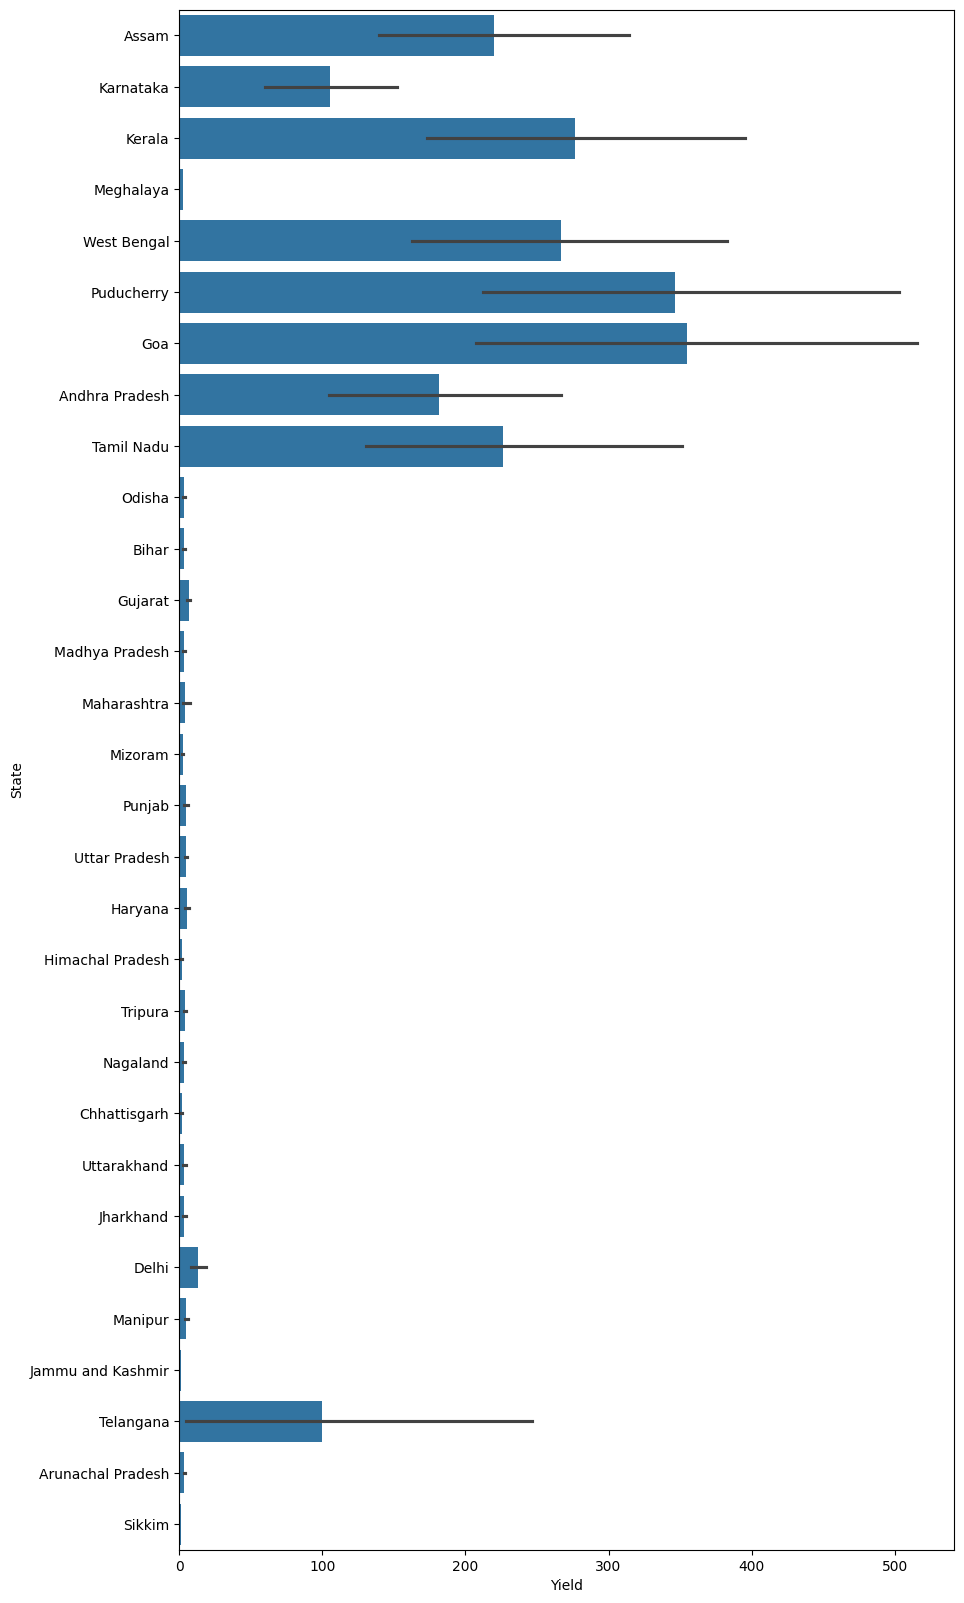

In [15]:
plt.figure(figsize = (10,20))
sns.barplot(y=df['State'],x=df['Yield'])

<Axes: xlabel='Yield', ylabel='State'>

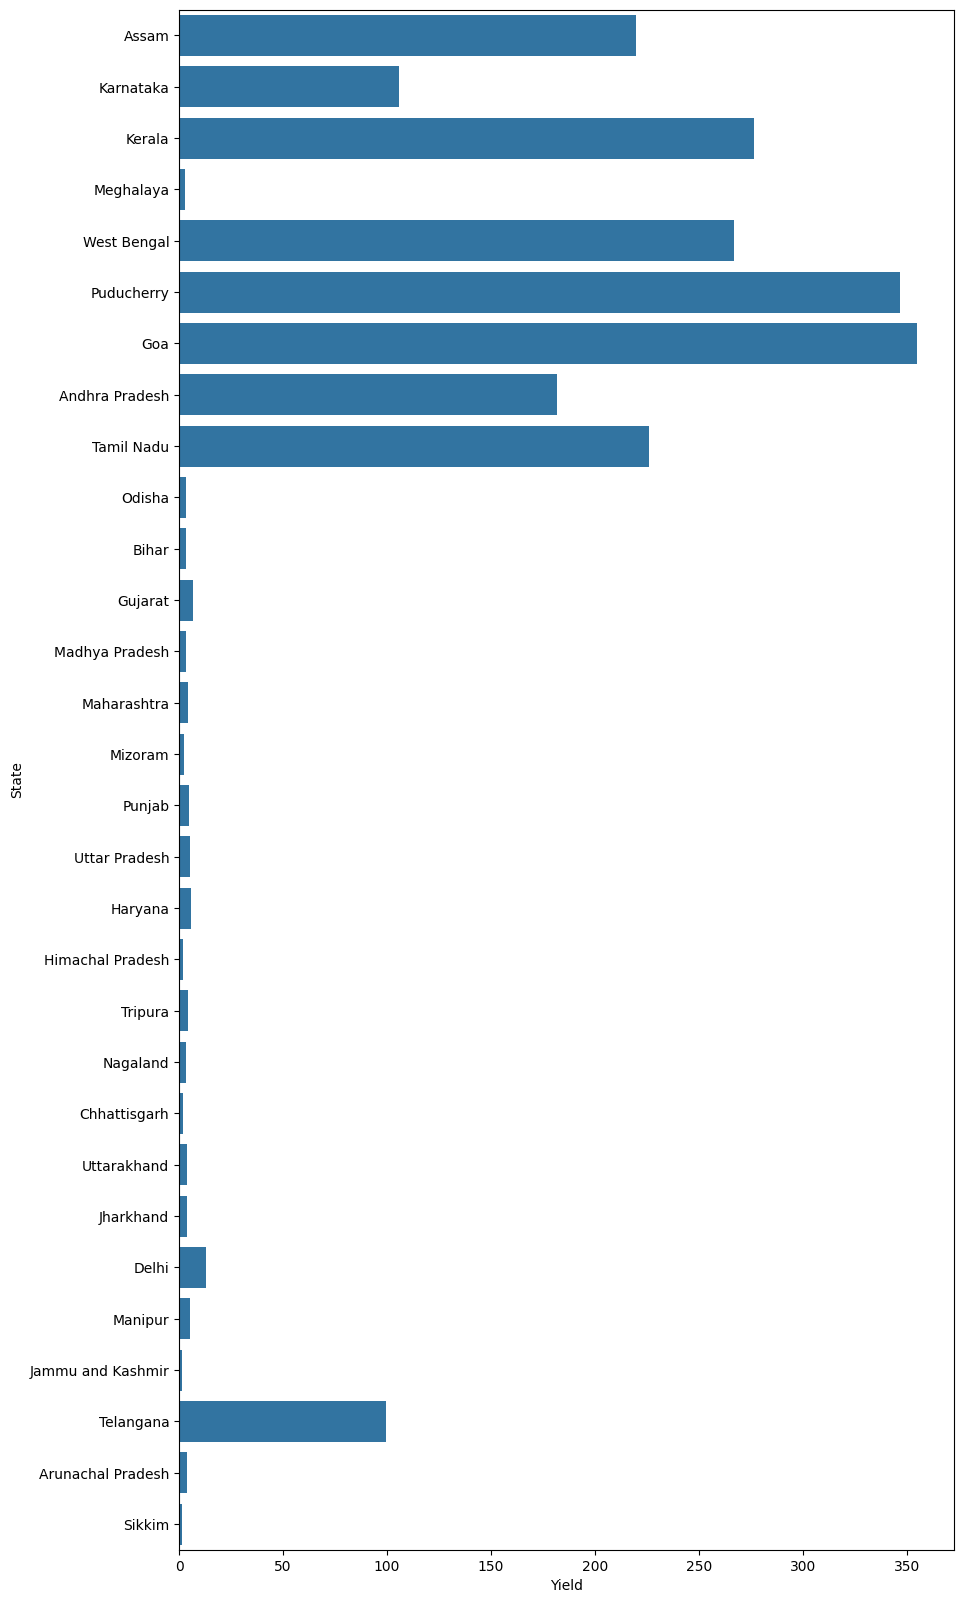

In [16]:
plt.figure(figsize = (10,20))
sns.barplot(y=df['State'],x=df['Yield'],errorbar = None)

In [17]:
# df = pd.get_dummies(df,columns=['Crop','Season','State'],drop_first = True)

In [18]:
x = df.drop(['Yield'],axis = 1)
y = df['Yield']

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [20]:
x_train.shape

(15751, 9)

In [21]:
x_test.shape

(3938, 9)

In [22]:
x_train

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
19466,Groundnut,2011,Kharif,Goa,357.0,1022,3340.395455,59804.64,117.81
17802,Barley,2007,Kharif,Delhi,75.0,196,677.500000,10005.00,12.00
7014,Moth,1999,Whole Year,Uttar Pradesh,204.0,84,883.400000,21650.52,55.08
14078,Barley,2014,Rabi,Uttarakhand,21054.0,24800,1287.400000,3178311.84,6947.82
8121,Cotton(lint),2002,Kharif,Madhya Pradesh,552393.0,379455,800.800000,52295045.31,138098.25
...,...,...,...,...,...,...,...,...,...
11284,Rice,2009,Summer,Uttar Pradesh,24695.0,61514,585.800000,3847974.90,4198.15
11964,Maize,2010,Rabi,West Bengal,17229.0,84356,1096.000000,2861909.19,4134.96
5390,Onion,2017,Rabi,Tamil Nadu,16518.0,153558,970.900000,2600593.92,6276.84
860,Castor seed,2001,Kharif,Karnataka,21799.0,16137,1002.900000,2226331.87,5667.74


<h2>Converting categorical to numerical and scaling the values</h2>

In [23]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

In [24]:
ohe = OneHotEncoder(drop = 'first') #,handle_unknown = 'ignore')
scaler = StandardScaler()

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehotencoder', ohe, ['Crop','Season','State']),
        ('scaler', scaler, ['Crop_Year','Area','Production','Annual_Rainfall','Fertilizer','Pesticide'])
    ]
)

In [26]:
preprocessor

ColumnTransformer(transformers=[('onehotencoder', OneHotEncoder(drop='first'),
                                 ['Crop', 'Season', 'State']),
                                ('scaler', StandardScaler(),
                                 ['Crop_Year', 'Area', 'Production',
                                  'Annual_Rainfall', 'Fertilizer',
                                  'Pesticide'])])

In [27]:
x_train_dummy = preprocessor.fit_transform(x_train)
x_test_dummy = preprocessor.transform(x_test)                          

In [28]:
x_train_dummy

<15751x94 sparse matrix of type '<class 'numpy.float64'>'
	with 140298 stored elements in Compressed Sparse Row format>

In [29]:
from sklearn.linear_model import LinearRegression , Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [30]:
# models = {
#     'lr':LinearRegression(),
#     'lss':Lasso(),
#     'rg':Ridge(),
#     'knr':KNeighborsRegressor(),
#     'dtr':DecisionTreeRegressor(),
#     'rf':RandomForestRegressor()
# }
# for name,mod in models.items():
#     mod.fit(x_train_dummy,y_train)
#     y_pred = mod.predict(x_test_dummy)
#     print(f"{name} MSE : {mean_squared_error(y_test,y_pred)} Score : {r2_score(y_test,y_pred)}")

Among all models, KNN Regressor performed best with the highest R² score of 0.93 and lowest MSE. However, since KNN is sensitive to data scaling and noise, Random Forest was also considered as a robust alternative for real-world applications.

In [31]:
rf = RandomForestRegressor(
    random_state = 42
)
rf.fit(x_train_dummy,y_train)
y_pred = rf.predict(x_test_dummy)
print("MSE:",mean_squared_error(y_test,y_pred),"Score :",r2_score(y_test,y_pred))

MSE: 10787.368266064788 Score : 0.9865366555777888


In [32]:
def prediction(Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide):
    input_df = pd.DataFrame([{
        'Crop': Crop,
        'Crop_Year': Crop_Year,
        'Season': Season,
        'State': State,
        'Area': Area,
        'Production': Production,
        'Annual_Rainfall': Annual_Rainfall,
        'Fertilizer': Fertilizer,
        'Pesticide': Pesticide
    }])
    transformed_features = preprocessor.transform(input_df)
    predicted_value = rf.predict(transformed_features)
    return predicted_value[0]

In [33]:
result = prediction(
    Crop = "Barley",
    Crop_Year = 2014,
    Season = 'Rabi       ',
    State= "Uttarakhand",
    Area = 21054.0,
    Production = 24800,
    Annual_Rainfall = 1287.400000,
    Fertilizer = 3178311.84,
    Pesticide = 6947.82
    )								
print(result)

1.2166044859499983


In [34]:
x_train

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
19466,Groundnut,2011,Kharif,Goa,357.0,1022,3340.395455,59804.64,117.81
17802,Barley,2007,Kharif,Delhi,75.0,196,677.500000,10005.00,12.00
7014,Moth,1999,Whole Year,Uttar Pradesh,204.0,84,883.400000,21650.52,55.08
14078,Barley,2014,Rabi,Uttarakhand,21054.0,24800,1287.400000,3178311.84,6947.82
8121,Cotton(lint),2002,Kharif,Madhya Pradesh,552393.0,379455,800.800000,52295045.31,138098.25
...,...,...,...,...,...,...,...,...,...
11284,Rice,2009,Summer,Uttar Pradesh,24695.0,61514,585.800000,3847974.90,4198.15
11964,Maize,2010,Rabi,West Bengal,17229.0,84356,1096.000000,2861909.19,4134.96
5390,Onion,2017,Rabi,Tamil Nadu,16518.0,153558,970.900000,2600593.92,6276.84
860,Castor seed,2001,Kharif,Karnataka,21799.0,16137,1002.900000,2226331.87,5667.74


In [35]:
x

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09
...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26


In [36]:
print(x_train['Season'].unique())

['Kharif     ' 'Whole Year ' 'Rabi       ' 'Autumn     ' 'Winter     '
 'Summer     ']


In [37]:
print(x_train['State'].unique())

['Goa' 'Delhi' 'Uttar Pradesh' 'Uttarakhand' 'Madhya Pradesh' 'Kerala'
 'Odisha' 'West Bengal' 'Tripura' 'Karnataka' 'Jammu and Kashmir'
 'Himachal Pradesh' 'Tamil Nadu' 'Gujarat' 'Nagaland' 'Meghalaya' 'Assam'
 'Maharashtra' 'Chhattisgarh' 'Mizoram' 'Andhra Pradesh' 'Haryana' 'Bihar'
 'Arunachal Pradesh' 'Manipur' 'Puducherry' 'Telangana' 'Punjab'
 'Jharkhand' 'Sikkim']


For Checking accuracy of the model prediction

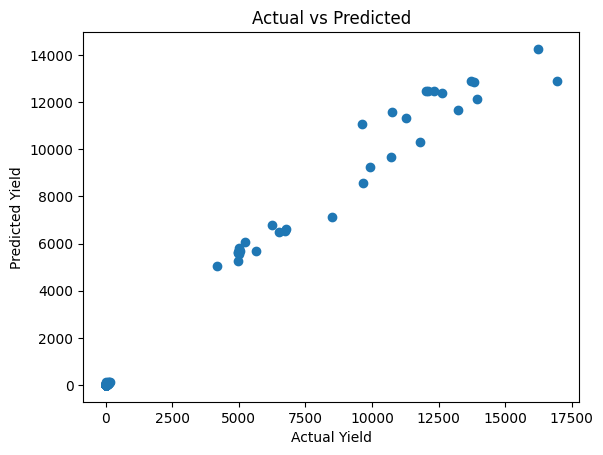

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted")
plt.show()

Does more rainfall increase yield?

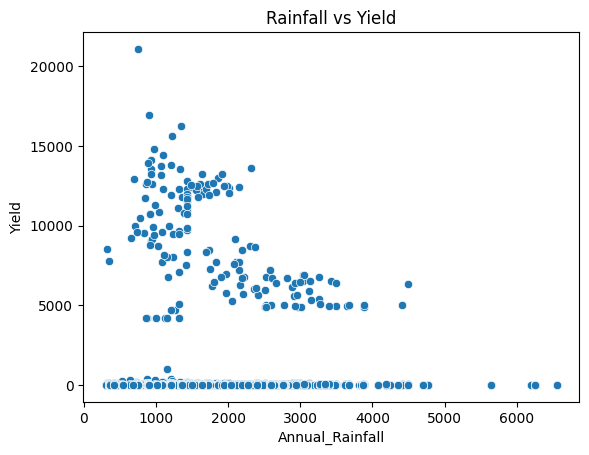

In [39]:
sns.scatterplot(x=df['Annual_Rainfall'], y=df['Yield'])
plt.title("Rainfall vs Yield")
plt.show()

Best season for crops

In [40]:
season_yield = df.groupby('Season')['Yield'].mean()
print(season_yield)

Season
Autumn           3.917482
Kharif           2.482002
Rabi             1.988518
Summer           2.997370
Whole Year     412.995463
Winter           5.287267
Name: Yield, dtype: float64


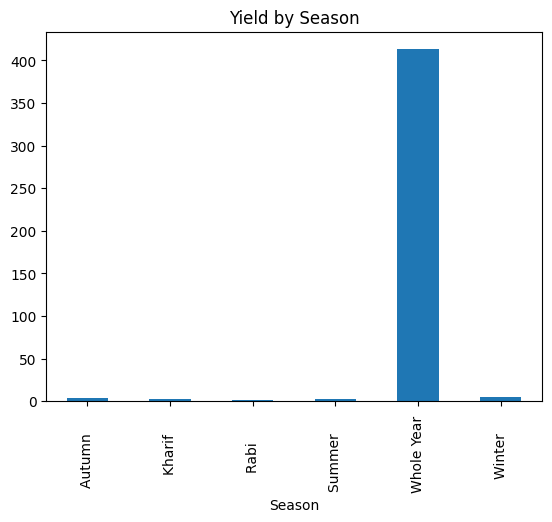

In [41]:
season_yield.plot(kind='bar')
plt.title("Yield by Season")
plt.show()

In [42]:
crop_yield = df.groupby('Crop')['Yield'].mean().sort_values(ascending = False)
print(crop_yield)

Crop
Coconut                  8652.000199
Sugarcane                  51.727439
Banana                     26.851128
Tapioca                    16.667301
Potato                     13.331718
Onion                      13.247525
Sweet potato                9.240788
Jute                        7.555393
Ginger                      6.442202
Mesta                       5.389204
Garlic                      4.544886
Maize                       3.427216
Turmeric                    3.325392
Cashewnut                   3.120438
Bajra                       2.427462
Rice                        2.218495
Tobacco                     2.110708
Dry chillies                2.078330
Arecanut                    2.073635
Wheat                       2.005086
Oilseeds total              1.995559
Cotton(lint)                1.797044
other oilseeds              1.789220
Barley                      1.595540
Peas & beans (Pulses)       1.393895
Groundnut                   1.360983
Sannhamp                    1.274

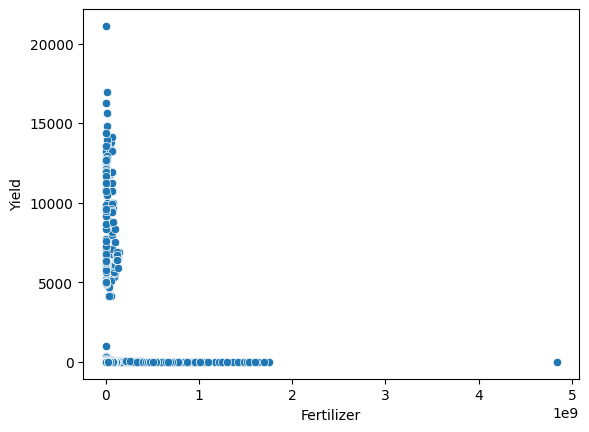

In [43]:
sns.scatterplot(x=df['Fertilizer'], y=df['Yield'])
plt.show()

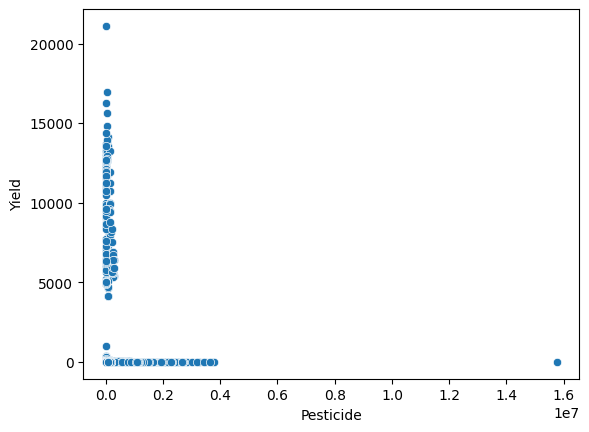

In [44]:
sns.scatterplot(x=df['Pesticide'], y=df['Yield'])
plt.show()

Q. what all features has more impact on the model 

In [45]:
importance = rf.feature_importances_

feature_names = preprocessor.get_feature_names_out()

import pandas as pd

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)
imp_df['Feature'] = imp_df['Feature'].str.replace('onehotencoder__', '')
print(imp_df)

                     Feature    Importance
8              Crop_Coconut   8.461287e-01
91   scaler__Annual_Rainfall  3.302581e-02
90        scaler__Production  2.468051e-02
70           State_Karnataka  2.040944e-02
92        scaler__Fertilizer  1.300117e-02
..                       ...           ...
40            Crop_Safflower  2.932173e-11
27                 Crop_Moth  2.881150e-11
18           Crop_Horse-gram  2.779042e-11
21              Crop_Khesari  9.123830e-12
34  Crop_Other Summer Pulses  4.716671e-12

[94 rows x 2 columns]


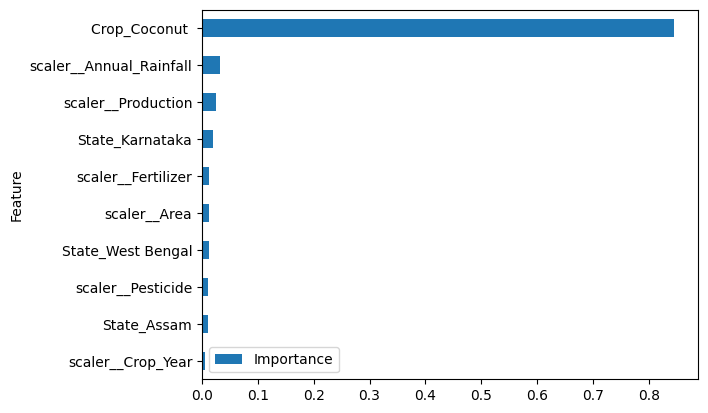

In [46]:
imp_df.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)
plt.gca().invert_yaxis()
plt.show()

In [48]:
train_score = rf.score(x_train_dummy, y_train)
test_score = rf.score(x_test_dummy, y_test)

print("Train:", train_score)
print("Test:", test_score)
# Train: 0.995640764876162
# Test: 0.9865366555777888

Train: 0.995640764876162
Test: 0.9865366555777888


In [49]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, x_train_dummy, y_train, cv=5, scoring='r2')
print(scores.mean())
# 0.9555101005444246

0.9555101005444246


In [50]:
import joblib

joblib.dump(rf, 'randomforest_regressor.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']